[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brilliantbeaver/alexpose/blob/main/experiments/sjepa/gavd6-pm/new_nb_09_01_mechanism_and_smoke_validation.ipynb)

# new_nb_09_01. Does the equivariance term actually do anything?

**Notebook 2 of 4, Idea 9 arm 2.**

**What the previous notebook settled.** `new_nb_09_00` fixed the question, the endpoint, and the
decision rule, and wrote them to `idea9_arm2_contract.json` before any data was seen. The endpoint is
**rho**, the normalised mirror-consistency residual, where **0 means exact mirror equivariance and is
the best value, 2 means the two representations are unrelated, and 4 means complete mirror blindness
and is the worst value**. The **anatomical mirror** `M` reflects the body and swaps left and right
landmark identities; both halves are required. Credit needs all three registered conditions to hold.

**What this notebook answers.** One narrower question that has to be settled first: when the training
loop adds the equivariance term `L_equiv`, does anything happen?

That question is not rhetorical. The natural way to write this loss is a no-op that trains nothing
while producing a loss curve pinned at zero, which looks exactly like immediate success. A slightly
less natural way is worse: it trains something, but the something is the readout rather than the
encoder. So before the ladder runs for hours, four checks run here in seconds.

1. **The trap is real.** The head-only version of the loss is exactly zero with exactly zero gradient.
2. **The fix reaches the encoder.** The through-the-encoder version is strictly positive and pushes
   gradient into encoder weights.
3. **The endpoint is calibrated.** rho reads exactly 0 on an encoder that is mirror-equivariant by
   construction and exactly 4 on one that is mirror-blind by construction, so its scale means what the
   contract says it means.
4. **The whole loop responds, but only for some forms of the term.** In a small end-to-end run of the
   real composite objective, one form of the term satisfies itself without moving rho at all, and two
   scale-invariant forms move it.

**The general lesson, which is the reason this notebook exists at all.** Verify that your loss is
capable of doing what you believe it does *before* you spend real compute running it. A loss curve is
not evidence that a constraint was imposed; it is evidence that some number went down. Four cheap
checks here cost seconds. Discovering the same facts after the ladder had run would have cost the whole
compute budget and produced a confident wrong answer.

**Every number in this notebook is a synthetic fixture.** The cohort is 30 synthetic sequences trained
for 30 epochs on a deliberately tiny toy model. Nothing here is a gait result, and no magnitude on this
page forecasts a magnitude on real data. Section 5 records where that temptation was given in to and
then retracted.

**What it produces.** `idea9_arm2_mechanism_validation.json` and its figure, carrying all four checks,
the gate outcome, and the variant selected for the real ladder.

**What comes next.** `new_nb_09_02` spends the real compute, using whichever form of the term survives
check 4.

**The two cells below** set up the environment and then define everything the checks need: the
S-JEPA model, the preprocessing, the antisymmetric head, the three candidate forms of `L_equiv`, rho
itself, and the synthetic fixture builder. Read their output only to confirm the output directory ends
in `idea9_arm2` and that a GPU device was found; nothing is measured yet.


In [1]:
from pathlib import Path
import os, sys, json, math, hashlib, copy, time, warnings

import numpy as np
import pandas as pd

RANDOM_SEED = 42


def find_project_root(start=None):
    env_root = os.getenv("ALEXPOSE_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TUTORIAL_DIR = PROJECT_ROOT / "experiments" / "sjepa" / "gavd6-pm"
try:
    from dotenv import load_dotenv
    load_dotenv(TUTORIAL_DIR / ".env", override=False)
    load_dotenv(PROJECT_ROOT / ".env", override=False)
except Exception:
    pass

TRUTHY = {"1", "true", "yes", "on"}
REQUESTED_MODE = os.getenv("GAVD_MODE", "smoke").strip().lower()
INCLUDE_AUGMENTED = os.getenv("SJEPA_INCLUDE_AUGMENTED_NORMAL", "0").strip().lower() in TRUTHY
ARTIFACT_ROOT = Path(os.getenv("GAVD_ARTIFACT_DIR", TUTORIAL_DIR / "work" / "artifacts")).expanduser()
CACHE_DIR = Path(os.getenv("GAVD_CACHE_DIR", TUTORIAL_DIR / "work" / "cache")).expanduser()
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

CONDITIONS = ["normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"]
MASK_KEYPOINTS = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]

# The six authorised left/right pairs the head, the signed target, and rho are all built from.
LEFT_RIGHT_PAIRS = [(11, 12), (23, 24), (25, 26), (27, 28), (29, 30), (31, 32)]
# The full 16-pair anatomical mirror, matching notebook 04's geometric_view flip.
FULL_MIRROR_PAIRS = [
    (1, 4), (2, 5), (3, 6), (7, 8), (9, 10),
    (11, 12), (13, 14), (15, 16), (17, 18), (19, 20), (21, 22),
    (23, 24), (25, 26), (27, 28), (29, 30), (31, 32),
]

# Arm-2 output lives in its own directory. Nothing here ever writes a baseline artifact name.
ARM2_DIR_NAME = "idea9_arm2"
BASELINE_CHECKPOINT_NAME = (
    "sjepa_curriculum_final_augmented.pt" if INCLUDE_AUGMENTED else "sjepa_curriculum_final.pt"
)


def artifact_dir_for(mode):
    return ARTIFACT_ROOT / mode


MODE = "smoke"  # this notebook is always a mechanism check, never a result
ARTIFACT_DIR = artifact_dir_for(REQUESTED_MODE)
ARM2_DIR = ARTIFACT_DIR / ARM2_DIR_NAME
ARM2_DIR.mkdir(parents=True, exist_ok=True)
print(f"mechanism checks write to: {ARM2_DIR}")

mechanism checks write to: /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real/idea9_arm2


In [2]:
import torch
from torch import nn
from torch.nn import functional as F


class SkeletonPatchEncoder(nn.Module):
    def __init__(self, frames=64, joints=33, coordinate_dim=3, segment_length=4,
                 embed_dim=64, depth=2, heads=4, dropout=0.0):
        super().__init__()
        if frames % segment_length:
            raise ValueError("frames must be divisible by segment_length")
        self.frames, self.joints = frames, joints
        self.coordinate_dim, self.segment_length = coordinate_dim, segment_length
        self.segments = frames // segment_length
        self.embed_dim = embed_dim
        self.patch_embed = nn.Linear(segment_length * coordinate_dim, embed_dim)
        self.time_pos = nn.Parameter(torch.randn(self.segments, embed_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=heads, dim_feedforward=embed_dim * 4,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

    def patchify(self, x):
        batch, frames, joints, channels = x.shape
        expected = (self.frames, self.joints, self.coordinate_dim)
        if (frames, joints, channels) != expected:
            raise ValueError(f"Expected [B, {expected}], received {x.shape}")
        patches = x.reshape(batch, self.segments, self.segment_length, joints, channels)
        patches = patches.permute(0, 1, 3, 2, 4).contiguous()
        return patches.flatten(3)

    def positioned_tokens(self, x):
        tokens = self.patch_embed(self.patchify(x))
        return tokens + self.time_pos[None, :, None, :] + self.joint_pos[None, None, :, :]

    def forward(self, x, keep_mask=None):
        tokens = self.positioned_tokens(x)
        batch = len(tokens)
        flat = tokens.reshape(batch, self.segments * self.joints, self.embed_dim)
        if keep_mask is not None:
            keep_mask = keep_mask.reshape(batch, -1)
            kept = keep_mask.sum(dim=1)
            if not torch.equal(kept, kept[:1].expand_as(kept)):
                raise ValueError("Each sample must keep the same number of tokens")
            flat = flat[keep_mask].reshape(batch, int(kept[0]), self.embed_dim)
        return self.norm(self.blocks(flat))


class SkeletonPredictor(nn.Module):
    def __init__(self, segments, joints, encoder_dim=64, predictor_dim=64,
                 depth=2, heads=4, dropout=0.0):
        super().__init__()
        self.segments, self.joints = segments, joints
        self.encoder_to_predictor = nn.Linear(encoder_dim, predictor_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, predictor_dim))
        nn.init.normal_(self.mask_token, std=0.02)
        self.time_pos = nn.Parameter(torch.randn(segments, predictor_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, predictor_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=predictor_dim, nhead=heads, dim_feedforward=predictor_dim * 4,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(predictor_dim)
        self.output = nn.Linear(predictor_dim, encoder_dim)

    def forward(self, visible_features, target_mask):
        batch = len(visible_features)
        target_mask = target_mask.reshape(batch, self.segments * self.joints)
        visible_mask = ~target_mask
        visible = self.encoder_to_predictor(visible_features)
        full = self.mask_token.expand(batch, self.segments * self.joints, -1).clone()
        full[visible_mask] = visible.reshape(-1, visible.shape[-1])
        positions = (self.time_pos[:, None, :] + self.joint_pos[None, :, :]).reshape(
            1, self.segments * self.joints, -1)
        full = full + positions
        predicted = self.output(self.norm(self.blocks(full)))
        return predicted[target_mask].reshape(batch, -1, predicted.shape[-1])


class SJEPAGait(nn.Module):
    def __init__(self, frames=64, joints=33, coordinate_dim=3, segment_length=4,
                 embed_dim=64, encoder_depth=2, predictor_depth=2, heads=4):
        super().__init__()
        self.view_encoder = SkeletonPatchEncoder(
            frames, joints, coordinate_dim, segment_length, embed_dim, encoder_depth, heads)
        self.target_encoder = copy.deepcopy(self.view_encoder)
        for parameter in self.target_encoder.parameters():
            parameter.requires_grad_(False)
        self.predictor = SkeletonPredictor(
            self.view_encoder.segments, joints, embed_dim, embed_dim, predictor_depth, heads)
        self.register_buffer("target_center", torch.zeros(embed_dim))

    def forward(self, view, target, target_mask):
        visible_features = self.view_encoder(view, keep_mask=~target_mask)
        predicted = self.predictor(visible_features, target_mask)
        with torch.no_grad():
            all_targets = self.target_encoder(target)
            flat_mask = target_mask.reshape(len(target), -1)
            selected = all_targets[flat_mask].reshape(len(target), -1, all_targets.shape[-1])
        return predicted, selected

    @torch.no_grad()
    def update_target(self, momentum):
        for target_parameter, view_parameter in zip(
                self.target_encoder.parameters(), self.view_encoder.parameters()):
            target_parameter.mul_(momentum).add_(view_parameter, alpha=1.0 - momentum)

    @torch.no_grad()
    def update_center(self, targets, beta=0.9):
        self.target_center.mul_(beta).add_(targets.mean(dim=(0, 1)), alpha=1.0 - beta)


def sjepa_cross_entropy(predicted, targets, center,
                        predictor_temperature=0.10, target_temperature=0.06):
    target_prob = torch.softmax(
        (targets - center[None, None, :]) / target_temperature, dim=-1).detach()
    prediction_log_prob = torch.log_softmax(predicted / predictor_temperature, dim=-1)
    return -(target_prob * prediction_log_prob).sum(dim=-1).mean()


def cosine_ema(step, total_steps, start=0.996, end=1.0):
    progress = min(max(step / max(total_steps - 1, 1), 0.0), 1.0)
    return end - (end - start) * (math.cos(math.pi * progress) + 1.0) / 2.0

def interpolate_low_visibility(sequence, threshold=0.45, max_gap=4):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
        raise ValueError(f"Expected [T, 33, 4], received {sequence.shape}")
    visibility = np.nan_to_num(sequence[..., 3], nan=0.0)
    finite = np.isfinite(sequence[..., :3]).all(axis=-1)
    valid = (visibility >= threshold) & finite
    filled = valid.copy()
    for joint in range(33):
        observed = np.flatnonzero(valid[:, joint])
        for left, right in zip(observed[:-1], observed[1:]):
            gap = int(right - left - 1)
            if not 0 < gap <= max_gap:
                continue
            fraction = (np.arange(1, gap + 1, dtype=np.float32) / (gap + 1))[:, None]
            sequence[left + 1:right, joint, :3] = (
                sequence[left, joint, :3][None, :] * (1.0 - fraction)
                + sequence[right, joint, :3][None, :] * fraction)
            filled[left + 1:right, joint] = True
        sequence[~filled[:, joint], joint, :3] = np.nan
    sequence[..., 3] = visibility
    return sequence, valid


def center_and_scale(sequence, eps=1e-6):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    xyz = sequence[..., :3]
    left_hip, right_hip = xyz[:, 23], xyz[:, 24]
    left_ok = np.isfinite(left_hip).all(axis=1)
    right_ok = np.isfinite(right_hip).all(axis=1)
    pelvis = np.full((len(xyz), 3), np.nan, dtype=np.float32)
    both = left_ok & right_ok
    pelvis[both] = 0.5 * (left_hip[both] + right_hip[both])
    pelvis[left_ok & ~right_ok] = left_hip[left_ok & ~right_ok]
    pelvis[right_ok & ~left_ok] = right_hip[right_ok & ~left_ok]
    pelvis_ok = np.isfinite(pelvis).all(axis=1)
    fallback = np.median(pelvis[pelvis_ok], axis=0) if pelvis_ok.any() else np.zeros(3)
    pelvis[~np.isfinite(pelvis).all(axis=1)] = fallback
    xyz = xyz - pelvis[:, None, :]
    shoulder_width = np.linalg.norm(xyz[:, 11, :2] - xyz[:, 12, :2], axis=-1)
    hip_width = np.linalg.norm(xyz[:, 23, :2] - xyz[:, 24, :2], axis=-1)
    body_scale = np.nanmedian(np.maximum(shoulder_width, hip_width))
    if not np.isfinite(body_scale) or body_scale < eps:
        body_scale = 1.0
    sequence[..., :3] = np.nan_to_num(xyz / body_scale, nan=0.0, posinf=0.0, neginf=0.0)
    return np.nan_to_num(sequence, nan=0.0, posinf=0.0, neginf=0.0)


def temporal_resize(array, frames):
    array = np.asarray(array)
    if len(array) == frames:
        return array.copy()
    if len(array) < 2:
        return np.repeat(array, frames, axis=0)
    old_t = np.linspace(0.0, 1.0, len(array))
    new_t = np.linspace(0.0, 1.0, frames)
    flat = array.reshape(len(array), -1)
    resized = np.stack([np.interp(new_t, old_t, flat[:, i]) for i in range(flat.shape[1])], axis=1)
    return resized.reshape(frames, *array.shape[1:])


def prepare_sequence(raw_sequence, frames):
    """raw_sequence: [T, 33, 4] -> (xyz [frames, 33, 3] float32, valid [frames, 33] bool)."""
    interpolated, valid = interpolate_low_visibility(raw_sequence)
    scaled = center_and_scale(interpolated)
    xyz = temporal_resize(scaled[..., :3], frames)
    valid_resized = temporal_resize(valid.astype(np.float32), frames) > 0.5
    return xyz.astype(np.float32), valid_resized


def anatomical_mirror_raw(coords, pairs=FULL_MIRROR_PAIRS):
    """Mirror the RAW [T, 33, 4] column so the SAME preprocessing can be re-run on the reflection."""
    mirrored = np.asarray(coords, dtype=np.float32).copy()
    mirrored[:, :, 0] = -mirrored[:, :, 0]
    for left, right in pairs:
        mirrored[:, [left, right], :] = mirrored[:, [right, left], :]
    return mirrored


def signed_left_minus_right(coords):
    """Item 05's frozen target: signed per-side excursion, left minus right, on preprocessed coords."""
    coords = np.asarray(coords, dtype=np.float64)[..., :3]
    total = 0.0
    for left, right in LEFT_RIGHT_PAIRS:
        total += coords[:, left, :].std(axis=0).sum() - coords[:, right, :].std(axis=0).sum()
    return float(total)

def anatomical_mirror_coords(coords):
    """Reflect the RAW skeleton: negate the sideways x coordinate and swap each left/right landmark.

    coords: [B, FRAMES, 33, 3] tensor. Differentiable passthrough, so gradients flow through the mirror.
    """
    mirrored = coords.clone()
    mirrored[..., 0] = -mirrored[..., 0]
    index = list(range(33))
    for left, right in FULL_MIRROR_PAIRS:
        index[left], index[right] = right, left
    return mirrored[:, :, index, :]


class AntisymmetricHead(nn.Module):
    """s = sum over pairs of ( f(L) - f(R) ), with f shared across joints and sides.

    Difference only, so the head negates under a swap of its own inputs by construction. In Arm 2 the
    head's parameters are trainable and join the optimiser, so L_equiv can shape the encoder and the
    head together.
    """

    def __init__(self, embed_dim, out_dim=4, hidden=32, pairs=LEFT_RIGHT_PAIRS):
        super().__init__()
        self.pairs = list(pairs)
        self.f = nn.Sequential(nn.Linear(embed_dim, hidden), nn.GELU(), nn.Linear(hidden, out_dim))

    def per_joint_feature(self, tokens):
        return tokens.mean(dim=1)

    def s_from_perjoint(self, per_joint):
        out = 0.0
        for left, right in self.pairs:
            out = out + (self.f(per_joint[:, left, :]) - self.f(per_joint[:, right, :]))
        return out

    def forward(self, tokens):
        return self.s_from_perjoint(self.per_joint_feature(tokens))

    def swapped(self, tokens):
        """Wiring self-check only. Returns -forward(tokens) by construction, so it trains nothing."""
        per_joint = self.per_joint_feature(tokens)
        swapped = per_joint.clone()
        for left, right in self.pairs:
            swapped[:, left, :] = per_joint[:, right, :]
            swapped[:, right, :] = per_joint[:, left, :]
        return self.s_from_perjoint(swapped)


def encoder_tokens_for_head(view_encoder, coords, segments, joints, embed_dim):
    return view_encoder(coords).reshape(len(coords), segments, joints, embed_dim)


def mirror_pair_signals(readout, view_encoder, coords, segments, embed_dim, joints=33):
    """Return ( s(enc(x)), s(enc(Mx)) ) with M the anatomical mirror on the RAW skeleton.

    The mirror is applied to raw coordinates and BOTH versions are run through the view encoder. A
    head-only token swap would be identically zero for every input and every parameter, so it would train
    nothing at all. Going through the encoder makes the residual a genuine constraint on encoder weights.
    """
    tokens = encoder_tokens_for_head(view_encoder, coords, segments, joints, embed_dim)
    tokens_mirrored = encoder_tokens_for_head(
        view_encoder, anatomical_mirror_coords(coords), segments, joints, embed_dim)
    return readout(tokens), readout(tokens_mirrored)


def equivariance_loss_absolute(head, view_encoder, coords, segments, embed_dim, joints=33):
    """nb_09b's term exactly as written: L = mean( ( s(enc(Mx)) + s(enc(x)) )^2 ).

    This has a degenerate solution. Because the head is trainable and shares the objective, the cheapest
    way to shrink the squared residual is to shrink s itself, which costs the encoder nothing. Notebook 01
    measures that collapse happening, which is why this variant is kept only as the documented baseline
    for comparison and is not used for the real ladder.
    """
    s, s_mirrored = mirror_pair_signals(head, view_encoder, coords, segments, embed_dim, joints)
    return ((s_mirrored + s) ** 2).mean()


def equivariance_loss_normalized(head, view_encoder, coords, segments, embed_dim,
                                 joints=33, eps=1e-6):
    """The scale-invariant repair, with the trainable head retained.

    L = mean_seq [ ||s(enc(Mx)) + s(enc(x))||^2 / ( 0.5 * (||s(enc(x))||^2 + ||s(enc(Mx))||^2) + eps ) ]

    Dividing by the signal's own magnitude removes the shrink-the-head escape route: scaling s by any
    constant leaves the ratio unchanged, so the only way down is for the encoder to actually represent the
    mirrored body as the sign flip of the original. Still label-free.
    """
    s, s_mirrored = mirror_pair_signals(head, view_encoder, coords, segments, embed_dim, joints)
    numerator = ((s_mirrored + s) ** 2).sum(dim=1)
    denominator = 0.5 * ((s ** 2).sum(dim=1) + (s_mirrored ** 2).sum(dim=1))
    return (numerator / (denominator + eps)).mean()


def equivariance_loss_parameter_free(view_encoder, coords, segments, embed_dim,
                                     joints=33, eps=1e-6):
    """The same scale-invariant residual with the head replaced by the identity feature map.

    This removes the head from the objective entirely, so there are no readout parameters that could be
    tuned to flatter the term. Its aggregation is a mean of per-sequence ratios, whereas the reported
    endpoint rho is a ratio of sums over the whole cohort, so the two are related but not identical.
    """
    s, s_mirrored = mirror_pair_signals(
        antisymmetric_contraction, view_encoder, coords, segments, embed_dim, joints)
    numerator = ((s_mirrored + s) ** 2).sum(dim=1)
    denominator = 0.5 * ((s ** 2).sum(dim=1) + (s_mirrored ** 2).sum(dim=1))
    return (numerator / (denominator + eps)).mean()


EQUIVARIANCE_VARIANTS = {
    "absolute": "nb_09b as written; has a shrink-the-head degenerate solution",
    "normalized": "scale-invariant, trainable head retained",
    "parameter_free": "scale-invariant, head removed from the objective",
}


def equivariance_term(variant, head, view_encoder, coords, segments, embed_dim, joints=33):
    """Dispatch to one equivariance variant, so a rung records which form it optimised."""
    if variant == "absolute":
        return equivariance_loss_absolute(head, view_encoder, coords, segments, embed_dim, joints)
    if variant == "normalized":
        return equivariance_loss_normalized(head, view_encoder, coords, segments, embed_dim, joints)
    if variant == "parameter_free":
        return equivariance_loss_parameter_free(view_encoder, coords, segments, embed_dim, joints)
    raise ValueError(f"unknown equivariance variant {variant!r}")


# --- the pre-registered PRIMARY endpoint: parameter-free, label-free, no fitting ----------------
def antisymmetric_contraction(tokens):
    """T(tokens) = sum over authorised pairs of ( tok_L - tok_R ) after a per-joint time mean.

    This is the AntisymmetricHead with f set to the identity, so it has no parameters at all. That makes
    it comparable across checkpoints without fitting anything and without a label.
    tokens: [B, SEGMENTS, 33, D] -> [B, D]
    """
    per_joint = tokens.mean(dim=1)
    out = 0.0
    for left, right in LEFT_RIGHT_PAIRS:
        out = out + (per_joint[:, left, :] - per_joint[:, right, :])
    return out


@torch.no_grad()
def mirror_residual_terms(encoder, xyz, segments, embed_dim, device, batch_size=16):
    """Per-sequence numerator and denominator of the normalised mirror-consistency residual rho.

    rho = mean_seq || T(enc(Mx)) + T(enc(x)) ||^2
        / mean_seq ( 0.5 * ( || T(enc(x)) ||^2 + || T(enc(Mx)) ||^2 ) )

    Scale, which is what makes rho readable without a target: rho = 0 means the encoder represents the
    mirrored body as the exact sign flip of the original along this axis, rho = 2 means the two are
    unrelated, and rho = 4 means the encoder is fully symmetric and cannot tell a body from its mirror.
    Lower is more mirror-honest. Returned per sequence so results can be aggregated by source video.
    """
    numerators, denominators = [], []
    for start in range(0, len(xyz), batch_size):
        chunk = torch.tensor(xyz[start:start + batch_size], dtype=torch.float32, device=device)
        tokens = encoder(chunk).reshape(len(chunk), segments, 33, embed_dim)
        tokens_mirrored = encoder(anatomical_mirror_coords(chunk)).reshape(
            len(chunk), segments, 33, embed_dim)
        s = antisymmetric_contraction(tokens)
        s_mirrored = antisymmetric_contraction(tokens_mirrored)
        numerators.append(((s_mirrored + s) ** 2).sum(dim=1).cpu().numpy())
        denominators.append((0.5 * ((s ** 2).sum(dim=1) + (s_mirrored ** 2).sum(dim=1))).cpu().numpy())
    return np.concatenate(numerators), np.concatenate(denominators)


def rho_from_terms(numerators, denominators):
    total = float(np.sum(denominators))
    if total <= 0:
        return float("nan")
    return float(np.sum(numerators) / total)


@torch.no_grad()
def head_signal_scale(head, encoder, xyz, segments, embed_dim, device, batch_size=16):
    """Mean ||s|| over the cohort. Evidence for or against the shrink-the-head degenerate solution."""
    norms = []
    for start in range(0, len(xyz), batch_size):
        chunk = torch.tensor(xyz[start:start + batch_size], dtype=torch.float32, device=device)
        tokens = encoder(chunk).reshape(len(chunk), segments, 33, embed_dim)
        norms.append(head(tokens).norm(dim=1).cpu().numpy())
    return float(np.mean(np.concatenate(norms)))

def uniform_neurologic_mask(valid_patch, mask_fraction=0.60, seed=None):
    """Sample eligible joint-time tokens uniformly, with no motion score. Verbatim from notebook 04."""
    valid_patch = np.asarray(valid_patch, dtype=bool)
    if valid_patch.ndim != 3 or valid_patch.shape[2] != 33:
        raise ValueError(f"Expected [B, S, 33], received {valid_patch.shape}")
    if not 0.0 < mask_fraction < 1.0:
        raise ValueError("mask_fraction must be between 0 and 1")
    rng = np.random.default_rng(seed)
    eligible_joint = np.zeros(33, dtype=bool)
    eligible_joint[MASK_KEYPOINTS] = True
    eligible = valid_patch & eligible_joint[None, None, :]
    counts = eligible.reshape(len(eligible), -1).sum(axis=1)
    if np.any(counts < 2):
        raise ValueError("Each sample needs at least two valid eligible tokens")
    n_mask = max(1, int(np.floor(counts.min() * mask_fraction)))
    n_mask = min(n_mask, int(counts.min()) - 1)
    mask = np.zeros_like(eligible)
    for index in range(len(mask)):
        candidates = np.flatnonzero(eligible[index].reshape(-1))
        mask[index].reshape(-1)[rng.choice(candidates, size=n_mask, replace=False)] = True
    forbidden = sorted(set(range(33)).difference(MASK_KEYPOINTS))
    if mask[:, :, forbidden].any():
        raise AssertionError("A forbidden keypoint entered the target mask")
    return mask


def geometric_view(x, max_degrees=8.0, translate=0.03, flip_probability=0.0):
    """Notebook 04's augmentation: y-axis rotation mixing x and z, plus a small translation.

    flip_probability stays 0.0 exactly as in notebook 04. Turning the flip on would put mirrored bodies
    into the JEPA branch itself, which would confound the equivariance term with a data augmentation.
    """
    view = x.clone()
    present = view.abs().sum(dim=-1) > 1e-8
    batch = len(view)
    angles = (torch.rand(batch, device=x.device) * 2.0 - 1.0) * math.radians(max_degrees)
    cosine, sine = torch.cos(angles), torch.sin(angles)
    original_x, original_z = view[..., 0].clone(), view[..., 2].clone()
    view[..., 0] = cosine[:, None, None] * original_x + sine[:, None, None] * original_z
    view[..., 2] = -sine[:, None, None] * original_x + cosine[:, None, None] * original_z
    view[..., :2] += (torch.rand(batch, 1, 1, 2, device=x.device) * 2.0 - 1.0) * translate
    if flip_probability > 0:
        raise ValueError("The flip augmentation must stay off; it would confound L_equiv")
    return view.masked_fill(~present[..., None], 0.0)


def authorized_pool(tokens, valid_patch):
    """Pool only valid tokens from the 12 authorised landmarks. Verbatim from notebook 04."""
    batch, segments, _, dimension = tokens.shape
    selected = tokens[:, :, MASK_KEYPOINTS].reshape(batch, -1, dimension)
    weights = valid_patch[:, :, MASK_KEYPOINTS].reshape(batch, -1).to(tokens.dtype)
    denominator = weights.sum(dim=1, keepdim=True).clamp_min(1.0)
    return (selected * weights.unsqueeze(-1)).sum(dim=1) / denominator


def off_diagonal(matrix):
    n, m = matrix.shape
    if n != m:
        raise ValueError("Covariance matrix must be square")
    return matrix.flatten()[:-1].view(n - 1, n + 1)[:, 1:].flatten()


def vicreg_terms(first, second, gamma=1.0, eps=1e-4):
    """VICReg invariance, variance hinge, and off-diagonal covariance. Verbatim from notebook 04."""
    invariance = F.mse_loss(first, second)
    first_std = torch.sqrt(first.var(dim=0, unbiased=False) + eps)
    second_std = torch.sqrt(second.var(dim=0, unbiased=False) + eps)
    variance = 0.5 * (F.relu(gamma - first_std).mean() + F.relu(gamma - second_std).mean())
    first_centered = first - first.mean(dim=0)
    second_centered = second - second.mean(dim=0)
    denominator = max(len(first) - 1, 1)
    first_cov = first_centered.T @ first_centered / denominator
    second_cov = second_centered.T @ second_centered / denominator
    covariance = (off_diagonal(first_cov).square().sum()
                  + off_diagonal(second_cov).square().sum()) / (2.0 * first.shape[1])
    return 25.0 * invariance + 25.0 * variance + covariance, invariance, variance, covariance


def condition_group_terms(representations, condition_ids, margin=1.0):
    """Bounded compactness and centroid separation on unit vectors. Verbatim from notebook 04."""
    unique = torch.unique(condition_ids)
    zero = representations.sum() * 0.0
    if len(unique) < 2:
        return zero, zero, torch.tensor(float("nan"), device=representations.device)
    normalized = F.normalize(representations, dim=1)
    centroids = torch.stack([
        F.normalize(normalized[condition_ids == value].mean(dim=0), dim=0) for value in unique])
    compactness = torch.stack([
        (normalized[condition_ids == value] - centroids[index]).square().sum(dim=1).mean()
        for index, value in enumerate(unique)]).mean()
    pairwise = (centroids[:, None] - centroids[None, :]).square().sum(dim=-1).clamp_min(1e-12).sqrt()
    upper = torch.triu(torch.ones_like(pairwise, dtype=torch.bool), diagonal=1)
    distances = pairwise[upper]
    return compactness, F.relu(margin - distances).square().mean(), distances.min()


def balanced_epoch_batches(data_by_condition, active_conditions, per_condition, rng):
    """Exhaustive, class-balanced replay batches for one epoch. Verbatim from notebook 04."""
    lengths = {c: len(data_by_condition[c]["xyz"]) for c in active_conditions}
    if min(lengths.values()) < 1:
        raise ValueError(f"Empty curriculum condition: {lengths}")
    steps = max(1, int(np.ceil(max(lengths.values()) / per_condition)))
    required = steps * per_condition
    orders = {}
    for condition in active_conditions:
        pieces = []
        while sum(len(piece) for piece in pieces) < required:
            pieces.append(rng.permutation(lengths[condition]))
        orders[condition] = np.concatenate(pieces)[:required]
    for step in range(steps):
        xyz_parts, valid_parts, label_parts = [], [], []
        for label, condition in enumerate(active_conditions):
            take = orders[condition][step * per_condition:(step + 1) * per_condition]
            xyz_parts.append(data_by_condition[condition]["xyz"][take])
            valid_parts.append(data_by_condition[condition]["valid"][take])
            label_parts.extend([label] * per_condition)
        permutation = rng.permutation(len(label_parts))
        yield (np.concatenate(xyz_parts)[permutation],
               np.concatenate(valid_parts)[permutation],
               np.asarray(label_parts, dtype=np.int64)[permutation])


class VICRegProjector(nn.Module):
    def __init__(self, dimension):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(dimension, dimension), nn.GELU(),
                                 nn.Linear(dimension, dimension))

    def forward(self, x):
        return self.net(x)


def pick_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

def synthetic_gait_sequence(condition="normal", frames=64, seed=0):
    """A code-path fixture, not a physiological disease simulation. Verbatim from notebook 04."""
    rng = np.random.default_rng(seed)
    phase = np.linspace(0.0, 4.0 * np.pi, frames, endpoint=False)
    seq = np.zeros((frames, 33, 4), dtype=np.float32)
    seq[..., 3] = 1.0
    base = {11: (0.42, 0.28), 12: (0.58, 0.28), 23: (0.45, 0.52), 24: (0.55, 0.52),
            25: (0.44, 0.70), 26: (0.56, 0.70), 27: (0.43, 0.89), 28: (0.57, 0.89),
            29: (0.42, 0.92), 30: (0.58, 0.92), 31: (0.39, 0.94), 32: (0.61, 0.94)}
    for joint, (x, y) in base.items():
        seq[:, joint, 0] = x
        seq[:, joint, 1] = y
    amplitude, lift = 0.045, 0.025
    if condition == "parkinsons":
        amplitude *= 0.45
        lift *= 0.45
    if condition == "myopathic":
        seq[:, [11, 12], 0] += 0.03 * np.sin(phase)[:, None]
        seq[:, [23, 24], 0] += 0.018 * np.sin(phase)[:, None]
    for joint, knee, foot, offset in [(27, 25, 31, 0.0), (28, 26, 32, np.pi)]:
        wave = np.sin(phase + offset)
        if condition == "stroke" and joint == 27:
            wave = 0.35 * wave
        if condition == "cerebralpalsy":
            seq[:, knee, 1] -= 0.045
            seq[:, joint, 1] -= 0.02
        seq[:, joint, 0] += amplitude * wave
        seq[:, knee, 0] += 0.4 * amplitude * wave
        seq[:, foot, 0] += amplitude * wave
        seq[:, joint, 1] -= lift * np.maximum(wave, 0.0)
        seq[:, foot, 1] -= 0.7 * lift * np.maximum(wave, 0.0)
    seq[..., :3] += rng.normal(0.0, 0.0025, seq[..., :3].shape)
    return seq


SMOKE_LEAN_MAGNITUDE = {"stroke": 1.0, "cerebralpalsy": 0.8, "parkinsons": 0.5,
                        "myopathic": 0.0, "normal": 0.0}


def plant_signed_lean(seq, sign, magnitude, seed):
    """Plant a lateral lean whose SIGN alternates between the two synthetic sources of a condition."""
    if magnitude == 0.0 or sign == 0:
        return seq
    rng = np.random.default_rng(seed)
    out = seq.copy()
    phase = np.linspace(0.0, 4.0 * np.pi, len(seq), endpoint=False)
    for left, right in LEFT_RIGHT_PAIRS:
        gain = 0.03 * magnitude * sign * rng.uniform(0.8, 1.2)
        out[:, left, 0] += gain * np.sin(phase)
        out[:, right, 0] -= gain * np.sin(phase)
    return out


def build_smoke_condition_data(frames, clips_per_source=3, seed=RANDOM_SEED):
    """Two synthetic sources per condition with opposite lean signs, so the axis has real structure."""
    data, counter = {}, 0
    for condition in CONDITIONS:
        xyz_list, valid_list, video_ids = [], [], []
        for source in range(2):
            sign = 1 if source == 0 else -1
            magnitude = SMOKE_LEAN_MAGNITUDE[condition]
            for _ in range(clips_per_source):
                base = synthetic_gait_sequence(condition=condition, frames=frames, seed=seed + counter)
                leaned = plant_signed_lean(base, sign, magnitude, seed=seed + 1000 + counter)
                xyz, valid = prepare_sequence(leaned, frames)
                xyz_list.append(xyz)
                valid_list.append(valid)
                video_ids.append(f"smoke_source_{condition}_{source}")
                counter += 1
        data[condition] = {"xyz": np.stack(xyz_list).astype(np.float32),
                           "valid": np.stack(valid_list),
                           "video_ids": video_ids}
    return data


print("model, preprocessing, equivariance, and training helpers defined.")
print(f"torch {torch.__version__}, device would be {pick_device()}")

model, preprocessing, equivariance, and training helpers defined.
torch 2.13.0, device would be mps


## 1. Check 1 of 4. The trap: a loss that looks right and trains nothing

**What we are about to do.** Measure the loss value and the gradient of the head-only form of
`L_equiv`, on random tokens.

**Why this is the first check.** Because if this form had been used, every later number in the series
would be meaningless, and nothing in the loss curve would have said so. This is the trap the earlier
`nb_09b` fell into.

**The argument, which we are about to stop trusting and start measuring.** The antisymmetric head
computes a pure difference over left and right landmark pairs. Swapping its own inputs therefore
negates its output exactly, for every input and every parameter value, because that is what the
arithmetic says, not because anything was learned. A loss written as

```
mean( ( s(swap of the head's own tokens) + s(tokens) )^2 )
```

is consequently zero as an algebraic identity. Penalising a swap of the head's *own* tokens asks the
head to satisfy a property it already satisfies by construction, which is not a training signal at all.

**What to look at in the output.** Three numbers.

- `wiring self-check slope of s(swap) against s` should be -1 to floating point. It reads
  **-1.0000000000**, which confirms the head is genuinely antisymmetric.
- `head-only loss value` should be zero. It reads **0.000e+00**, exactly.
- `head-only total gradient into the head` should be zero. It reads **0.000e+00**, exactly.

**What we may conclude.** A term with zero gradient cannot train anything, no matter how long it runs
or how large its weight is set. The head-only formulation is not a weak constraint or a poorly scaled
one; it is an identity, and it is disqualified as a training loss.

**What we may not conclude.** That the swap identity itself is useless. It remains valuable as a wiring
self-check on the head, which is exactly how the slope above is used. It simply cannot be the loss.

These are synthetic fixture numbers on random tokens, and that is sufficient here, because the claim
being tested is algebraic rather than empirical.


In [3]:
torch.manual_seed(RANDOM_SEED)
head_check = AntisymmetricHead(32, out_dim=4)
tokens_check = torch.randn(6, 8, 33, 32)

with torch.no_grad():
    s_value = head_check(tokens_check)
    s_swapped = head_check.swapped(tokens_check)
wiring_slope = float(np.polyfit(s_value.reshape(-1).numpy(), s_swapped.reshape(-1).numpy(), 1)[0])

head_only_loss = ((head_check.swapped(tokens_check) + head_check(tokens_check)) ** 2).mean()
head_only_value = float(head_only_loss.detach())
head_check.zero_grad(set_to_none=True)
head_only_loss.backward()
head_only_grad = sum(float(p.grad.abs().sum()) for p in head_check.parameters() if p.grad is not None)

print(f"wiring self-check slope of s(swap) against s : {wiring_slope:+.10f}   (exactly -1 by construction)")
print(f"head-only loss value                        : {head_only_value:.3e}")
print(f"head-only total gradient into the head      : {head_only_grad:.3e}")
if abs(wiring_slope + 1.0) > 1e-6:
    raise AssertionError("the head must negate under a swap of its own inputs")
if head_only_value > 1e-12 or head_only_grad > 1e-12:
    raise AssertionError("the head-only loss must be an exact no-op")
print("\nCHECK 1 PASSED: the head-only formulation is an exact no-op. It cannot be the training loss.")

wiring self-check slope of s(swap) against s : -1.0000000000   (exactly -1 by construction)
head-only loss value                        : 0.000e+00
head-only total gradient into the head      : 0.000e+00

CHECK 1 PASSED: the head-only formulation is an exact no-op. It cannot be the training loss.


## 2. Check 2 of 4. The fix: put the mirror on the skeleton, not on the tokens

**What we are about to do.** Run three candidate forms of `L_equiv` through a deliberately
non-equivariant encoder and measure how much gradient each one delivers to the encoder's own weights.

**Why this check follows check 1.** Check 1 showed what fails. This one has to show that the proposed
replacement does not fail in the same way, and the test has to be a gradient measurement rather than an
argument, for the same reason as before.

**The repair.** Reflect the raw skeleton, negating the sideways coordinate and swapping every left and
right landmark identity, then run *both* the original and the reflection through the encoder. The
encoder has no built-in reason to represent a reflected body as the left-right swap of its own tokens,
so the residual is genuinely nonzero and its gradient reaches encoder weights. The test encoder here is
a plain per-joint linear map over raw coordinates, so nothing about it respects the mirror and the
residual has no way to be trivially zero.

**Three candidate forms are carried forward,** because check 4 will show that the difference between
them decides whether the experiment measures anything at all.

- **`absolute`** is `nb_09b`'s term exactly as written and as registered in the contract,
  `mean( ( s(enc(Mx)) + s(enc(x)) )^2 )`, with a trainable head `s`.
- **`normalized`** divides each sequence's squared residual by that sequence's own signal magnitude,
  keeping the trainable head.
- **`parameter_free`** uses the same scale-invariant ratio with the head replaced by the fixed identity
  feature map, so the objective has no readout parameters at all.

**What to look at in the output.** The `grad encoder` column, which must be nonzero for all three, and
the `grad head` column for `parameter_free`, which must be exactly zero.

- `absolute` reaches the encoder with gradient norm **0.522**.
- `normalized` reaches it with **6.120**.
- `parameter_free` reaches it with **1.873**, and delivers **0.000e+00** into the head, which is not an
  empirical finding but a structural one: that variant has no head parameters in its computation, so
  there is nothing there to receive gradient.

**What we may conclude.** All three forms are label-free and all three are genuine constraints on
encoder weights rather than identities. The property check 1's formulation can never have is present in
all three.

**What we may not conclude, and this is the important part.** Nothing about whether any of these forms
actually changes what an encoder learns. Delivering gradient to the encoder is necessary but not
sufficient, and check 4 is where the difference shows up. Note also that the size of these gradient
norms carries no ranking information: they are single-batch norms on one synthetic fixture, and a larger
norm here is not a better term. All numbers on this page are synthetic fixtures.


In [4]:
class NonEquivariantEncoder(nn.Module):
    """A plain per-joint linear map over raw coordinates. Nothing about it respects the mirror."""

    def __init__(self, frames, segments, dim):
        super().__init__()
        self.frames, self.segments, self.dim = frames, segments, dim
        self.proj = nn.Linear(frames * 3, segments * dim)

    def forward(self, x):
        batch = len(x)
        per_joint = x.permute(0, 2, 1, 3).reshape(batch, 33, self.frames * 3)
        out = self.proj(per_joint).reshape(batch, 33, self.segments, self.dim)
        return out.permute(0, 2, 1, 3).reshape(batch, self.segments * 33, self.dim)


torch.manual_seed(RANDOM_SEED + 3)
probe_frames, probe_segments, probe_dim = 8, 2, 32
probe_coords = torch.randn(4, probe_frames, 33, 3)
gradient_evidence = {}
for variant in EQUIVARIANCE_VARIANTS:
    torch.manual_seed(RANDOM_SEED + 3)
    probe_encoder = NonEquivariantEncoder(probe_frames, probe_segments, probe_dim)
    probe_head = AntisymmetricHead(probe_dim, out_dim=4)
    loss = equivariance_term(variant, probe_head, probe_encoder, probe_coords,
                             probe_segments, probe_dim)
    loss.backward()
    gradient_evidence[variant] = {
        "loss": float(loss.detach()),
        "grad_head": sum(float(p.grad.norm()) for p in probe_head.parameters() if p.grad is not None),
        "grad_encoder": sum(float(p.grad.norm()) for p in probe_encoder.parameters()
                            if p.grad is not None),
    }
    row = gradient_evidence[variant]
    print(f"{variant:15s} loss {row['loss']:.6e}   grad head {row['grad_head']:.3e}   "
          f"grad encoder {row['grad_encoder']:.3e}")
    if row["loss"] <= 1e-8:
        raise AssertionError(f"{variant} must be strictly positive on a non-equivariant encoder")
    if row["grad_encoder"] <= 1e-8:
        raise AssertionError(f"{variant} must deliver gradient to the encoder")
if gradient_evidence["parameter_free"]["grad_head"] > 0.0:
    raise AssertionError("the parameter-free variant must not touch head parameters at all")
print("\nCHECK 2 PASSED: every through-the-encoder variant reaches encoder weights.")

absolute        loss 1.014919e-01   grad head 1.185e+00   grad encoder 5.221e-01
normalized      loss 1.434148e+00   grad head 1.196e+01   grad encoder 6.120e+00
parameter_free  loss 1.043202e+00   grad head 0.000e+00   grad encoder 1.873e+00

CHECK 2 PASSED: every through-the-encoder variant reaches encoder weights.


## 3. Check 3 of 4. Calibrating the primary endpoint against two encoders built by hand

**What we are about to do.** Read rho on two toy encoders whose correct answers are known in advance by
construction, plus a randomly initialised real encoder for reference, and check that rho does not depend
on which member of a mirror pair is called the original.

**Why this check is necessary.** The contract *claims* that rho reads 0 for a mirror-equivariant
encoder, about 2 when the two representations are unrelated, and 4 for a mirror-blind one. The entire
verdict of this series will be read off that scale, so the claim needs demonstrating rather than
asserting. This is instrument calibration, and the general principle is worth naming: you earn the right
to trust a measurement on cases whose answer you do not know by first showing that it returns the right
answer on cases whose answer you do.

**How the two known-answer cases are built.**

The **mirror-equivariant** toy encoder takes the absolute value of the sideways coordinate before its
projection. Under the anatomical mirror, the left slot receives the reflected right joint, whose
sideways magnitude is unchanged, so the encoder's tokens for the mirrored body are exactly the
left-right swap of its tokens for the original. That is precisely the property `L_equiv` asks for, so
rho **must** be 0.

The **mirror-blind** toy encoder gives every joint a fixed per-slot code plus a body-level summary that
is itself mirror invariant. Nothing in its tokens records which side the motion happened on, so the
mirrored body maps to the same tokens rather than to their swap, and the two branches add rather than
cancel. rho **must** be 4.

A **randomly initialised real encoder**, the same architecture the ladder will train, is measured
alongside them as an unconstrained reference point.

**What to look at in the output.** Four numbers.

- `mirror_equivariant_by_construction` reads **0.000000**, the exact bottom of the scale.
- `mirror_blind_by_construction` reads **4.000000**, the exact top of the scale.
- `randomly_initialised_real_encoder` reads **3.857786**, close to mirror blind.
- The involution check `|rho(x) - rho(Mx)|` reads **0.000e+00**, so rho gives the same answer whichever
  member of the mirror pair is fed in first. `M` is an involution, and rho respects that.

**What we may conclude.** The scale in the contract is the scale these numbers are on. rho is a
correctly calibrated instrument, its two ends are exact rather than approximate, and it is not sensitive
to an arbitrary labelling choice.

**What we may not conclude, and this trips readers up.** That 3.858 forecasts anything about real
encoders. It is one draw from a random initialisation of a small toy configuration, measured on
synthetic fixtures. Section 5 returns to exactly this point, because the first version of this notebook
did read a forecast into it and was wrong.


In [5]:
class MirrorEquivariantToyEncoder(nn.Module):
    """Per-joint projection of ( |x|, y, z ). Mirror-equivariant by construction, so rho must be 0."""

    def __init__(self, frames, segment_length, dim):
        super().__init__()
        self.segments = frames // segment_length
        self.segment_length = segment_length
        self.proj = nn.Linear(3, dim)

    def forward(self, x):
        batch = len(x)
        pooled = x.reshape(batch, self.segments, self.segment_length, 33, 3).mean(dim=2)
        features = torch.stack([pooled[..., 0].abs(), pooled[..., 1], pooled[..., 2]], dim=-1)
        return self.proj(features).reshape(batch, self.segments * 33, -1)


class MirrorBlindToyEncoder(nn.Module):
    """Per-slot code plus a mirror-invariant body summary. Side information is absent, so rho must be 4."""

    def __init__(self, frames, segment_length, dim):
        super().__init__()
        self.segments = frames // segment_length
        self.segment_length = segment_length
        self.joint_code = nn.Parameter(torch.randn(33, dim))
        self.proj = nn.Linear(3, dim)

    def forward(self, x):
        batch = len(x)
        pooled = x.reshape(batch, self.segments, self.segment_length, 33, 3).mean(dim=2)
        summary = torch.stack([pooled[..., 0].abs(), pooled[..., 1], pooled[..., 2]], dim=-1).mean(dim=2)
        tokens = self.joint_code[None, None, :, :] + self.proj(summary)[:, :, None, :]
        return tokens.reshape(batch, self.segments * 33, -1)


CAL_FRAMES, CAL_SEGMENT, CAL_DIM = 32, 4, 32
CAL_SEGMENTS = CAL_FRAMES // CAL_SEGMENT
calibration_data = build_smoke_condition_data(CAL_FRAMES)
calibration_xyz = np.concatenate([calibration_data[c]["xyz"] for c in CONDITIONS])
cpu = torch.device("cpu")

torch.manual_seed(RANDOM_SEED)
calibration_encoders = {
    "mirror_equivariant_by_construction": MirrorEquivariantToyEncoder(CAL_FRAMES, CAL_SEGMENT, CAL_DIM),
    "mirror_blind_by_construction": MirrorBlindToyEncoder(CAL_FRAMES, CAL_SEGMENT, CAL_DIM),
    "randomly_initialised_real_encoder": SkeletonPatchEncoder(
        frames=CAL_FRAMES, segment_length=CAL_SEGMENT, embed_dim=CAL_DIM, depth=2, heads=4),
}
calibration_rho = {}
for name, encoder in calibration_encoders.items():
    encoder.eval()
    numerators, denominators = mirror_residual_terms(
        encoder, calibration_xyz, CAL_SEGMENTS, CAL_DIM, cpu)
    calibration_rho[name] = rho_from_terms(numerators, denominators)
    print(f"rho = {calibration_rho[name]:.6f}   {name}")

# rho must be blind to which of the pair is called the original, because M is an involution.
equivariant_encoder = calibration_encoders["mirror_equivariant_by_construction"]
mirrored_xyz = np.stack([anatomical_mirror_raw(
    np.concatenate([x, np.ones((len(x), 33, 1), dtype=np.float32)], axis=2))[..., :3]
    for x in calibration_xyz])
numerators_m, denominators_m = mirror_residual_terms(
    equivariant_encoder, mirrored_xyz, CAL_SEGMENTS, CAL_DIM, cpu)
involution_gap = abs(rho_from_terms(numerators_m, denominators_m)
                     - calibration_rho["mirror_equivariant_by_construction"])
print(f"\ninvolution check, |rho(x) - rho(Mx)| = {involution_gap:.3e}   (must be ~0)")

if calibration_rho["mirror_equivariant_by_construction"] > 1e-6:
    raise AssertionError("rho must be 0 for an encoder that is mirror-equivariant by construction")
if abs(calibration_rho["mirror_blind_by_construction"] - 4.0) > 1e-6:
    raise AssertionError("rho must be 4 for an encoder that is mirror-blind by construction")
if involution_gap > 1e-6:
    raise AssertionError("rho must not depend on which member of the mirror pair is the original")
print("\nCHECK 3 PASSED: rho reads 0 at exact equivariance and 4 at exact mirror blindness.")

rho = 0.000000   mirror_equivariant_by_construction
rho = 4.000000   mirror_blind_by_construction
rho = 3.857786   randomly_initialised_real_encoder

involution check, |rho(x) - rho(Mx)| = 0.000e+00   (must be ~0)

CHECK 3 PASSED: rho reads 0 at exact equivariance and 4 at exact mirror blindness.


## 4. Check 4 of 4. The check that changed the design: a loss can fall to zero and teach the encoder nothing

**What we are about to do.** Run four small end-to-end rungs of the real composite objective on
synthetic fixtures, 30 sequences for 30 epochs each: one control with the term switched off, and one
for each of the three candidate forms at weight 0.02. Then compare them on rho.

**Why the previous three checks were not enough.** Checks 1 to 3 are about arithmetic: what is
identically zero, what receives gradient, what a metric reads on known inputs. This check asks a
behavioural question instead. Inside the real composite objective, alongside the JEPA cross-entropy, the
VICReg terms and the label-aware group terms, does adding the equivariance term change what the encoder
*learns*?

### The detective story, in the order it actually happened

**The first reading, which was wrong.** The first version of this notebook ran only `nb_09b`'s term as
written, the `absolute` form, and concluded that it worked. The term fell from **0.550** to **0.003**
over the 30 fixture epochs, a reduction of about **184-fold**. Read on its own, a loss falling by more
than two orders of magnitude looks exactly like an encoder learning mirror equivariance.

**The number that contradicted it.** rho did not move. The `absolute` rung finished at **3.922** on the
view encoder against the control's **3.931**, an improvement of only **0.0096**. The control rung's own
epoch-to-epoch wobble over its last ten epochs has a standard deviation of **0.0164**, so a strict gate
at three times that wobble sits at **0.0492**. The improvement was five times *smaller* than the gate.
The loss went to nearly zero and the representation was left where the control left it.

**The diagnosis.** The head `s` is trainable and shares the objective. The `absolute` residual is an
unnormalised squared magnitude, so the cheapest way to shrink it is to shrink `s` itself, which costs the
encoder nothing at all. And that is what the optimiser did: the head's mean signal magnitude fell from
**0.440** to **0.092**, a **4.77-fold** shrink. In plain terms, **the loss satisfied itself by shrinking
the readout instead of changing the encoder.** This is the same class of mistake as check 1's no-op, one
level deeper. The term is not algebraically zero; it is merely satisfiable without doing the work.

**The repair.** Make the term scale-invariant by dividing the squared residual by the mean squared norm
of the two branches:

```
L = mean_seq [ || s(enc(Mx)) + s(enc(x)) ||^2
             / ( 0.5 * ( || s(enc(x)) ||^2 + || s(enc(Mx)) ||^2 ) + eps ) ]
```

Scaling `s` by any constant now leaves the value unchanged, so shrinking the head buys nothing, and the
only remaining way down is for the encoder to genuinely represent a mirrored body as the sign flip of the
original. `normalized` is this expression with the trainable head. `parameter_free` is the same
expression with `s` replaced by the fixed antisymmetric contraction, so it has no head parameters to
shrink in the first place.

### What to look at in the output of the next cell

The gate is printed first: the control finishes at rho **3.93193** on the view encoder with a late-epoch
standard deviation of **0.01641**, so an improvement counts only if it exceeds **0.04922**. Then read the
bakeoff table by rung.

- **D0 control, w = 0.** rho_view 3.93193 by definition, improvement 0.0.
- **E1 `absolute`.** Improvement **0.00961**, `beats_gate` **False**. Term fold reduction **184.16**,
  head scale fold shrink **4.77**. This is the documented failure mode, printed explicitly at the bottom
  of the cell.
- **E1 `normalized`.** Improvement **0.08379**, `beats_gate` **True**. Head scale barely moves,
  0.551 to 0.513.
- **E1 `parameter_free`.** Improvement **2.03419**, `beats_gate` **True**, by far the largest movement.

One column needs care, because it is easy to over-read. `head_scale_fold_shrink` is **2.82** for the
control, whose head is not in the objective at all, and **3.81** for `parameter_free`, whose head is
also not in the objective. So a shrinking head is not by itself the signature of the degenerate solution.
The signature is a shrinking head *together with* the term collapsing *while* rho stays put, which is
what only `absolute` shows.

**Why `parameter_free` is selected for the real ladder.** Both scale-invariant forms clear the gate, and
the cell selects the larger improvement, which is `parameter_free`. There is a structural reason to
prefer it beyond its margin: it has no head parameters at all, so there is nothing left to shrink and the
degenerate solution is unavailable to it by construction rather than by measurement. The gate outcome and
the selection are written into the bundle so the real ladder cannot silently use a different form.

**What we may conclude.** At least one form of the equivariance term is capable of moving the primary
endpoint by more than the control's own trajectory noise, on fixtures. The registered `absolute` form is
not, and the reason is a specific, identified degeneracy rather than bad luck or a weight that needed
tuning.

**What we may not conclude.** Anything about gait, about real encoders, about seeds, or about
representation quality. Every number above is a synthetic fixture from a one-layer 32-dimensional toy
model on 30 synthetic sequences.

**The cell after the bakeoff** plots the three trajectories side by side, rho, head signal magnitude, and
the optimised term on a log scale, and writes `idea9_arm2_mechanism_validation.json`. The middle panel is
the one worth studying: it shows the `absolute` rung's head collapsing while the left panel shows its rho
flat.


In [6]:
MINI_FRAMES, MINI_SEGMENT, MINI_DIM = 32, 4, 32
MINI_SEGMENTS = MINI_FRAMES // MINI_SEGMENT
MINI_EPOCHS = 30
MINI_SAMPLES_PER_CONDITION = 2
MINI_EQUIV_WEIGHT = 0.02
mini_data = build_smoke_condition_data(MINI_FRAMES)
mini_xyz = np.concatenate([mini_data[c]["xyz"] for c in CONDITIONS])
print(f"mini cohort: {len(mini_xyz)} synthetic sequences, {MINI_EPOCHS} epochs per rung")


def run_mini_rung(equiv_weight, variant="normalized", seed=RANDOM_SEED, device=cpu):
    """One small end-to-end rung of the real composite objective, with the equivariance term on or off."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = SJEPAGait(frames=MINI_FRAMES, segment_length=MINI_SEGMENT, embed_dim=MINI_DIM,
                      encoder_depth=1, predictor_depth=1, heads=4).to(device)
    projector = VICRegProjector(MINI_DIM).to(device)
    head = AntisymmetricHead(MINI_DIM, out_dim=4).to(device)
    trainable = [*model.view_encoder.parameters(), *model.predictor.parameters(),
                 *projector.parameters(), *head.parameters()]
    optimizer = torch.optim.AdamW(trainable, lr=1e-3, betas=(0.9, 0.95), weight_decay=0.05)
    rng = np.random.default_rng(seed)
    rows, step = [], 0
    for epoch in range(MINI_EPOCHS):
        model.train()
        equiv_values = []
        for xyz_np, valid_np, labels_np in balanced_epoch_batches(
                mini_data, CONDITIONS, MINI_SAMPLES_PER_CONDITION, rng):
            coordinates = torch.tensor(xyz_np, dtype=torch.float32, device=device)
            valid = torch.tensor(valid_np, dtype=torch.bool, device=device)
            labels = torch.tensor(labels_np, dtype=torch.long, device=device)
            valid_patch = valid.reshape(len(valid), MINI_SEGMENTS, MINI_SEGMENT, 33).all(dim=2)
            mask_np = uniform_neurologic_mask(valid_patch.cpu().numpy(), 0.60, seed=seed + 100000 + step)
            target_mask = torch.tensor(mask_np, dtype=torch.bool, device=device)
            view_a = geometric_view(coordinates)
            view_b = geometric_view(coordinates)

            prediction, target = model(view_a, coordinates, target_mask)
            jepa_loss = sjepa_cross_entropy(prediction, target, model.target_center)
            tokens_a = model.view_encoder(view_a).reshape(len(view_a), MINI_SEGMENTS, 33, MINI_DIM)
            tokens_b = model.view_encoder(view_b).reshape(len(view_b), MINI_SEGMENTS, 33, MINI_DIM)
            pooled_a = authorized_pool(tokens_a, valid_patch)
            pooled_b = authorized_pool(tokens_b, valid_patch)
            vicreg_loss, _, _, _ = vicreg_terms(projector(pooled_a), projector(pooled_b))
            compactness, separation, _ = condition_group_terms(pooled_a, labels)
            equiv = equivariance_term(variant, head, model.view_encoder, coordinates,
                                      MINI_SEGMENTS, MINI_DIM)
            total = (jepa_loss + 0.05 * vicreg_loss + 0.25 * (compactness + separation)
                     + equiv_weight * equiv)

            optimizer.zero_grad(set_to_none=True)
            total.backward()
            if any(p.grad is not None for p in model.target_encoder.parameters()):
                raise AssertionError("the target encoder must stay frozen")
            torch.nn.utils.clip_grad_norm_(trainable, max_norm=1.0)
            optimizer.step()
            model.update_target(cosine_ema(step, MINI_EPOCHS * 3, start=0.996))
            model.update_center(target, beta=0.9)
            equiv_values.append(float(equiv.detach()))
            step += 1

        model.eval()
        view_terms = mirror_residual_terms(
            model.view_encoder, mini_xyz, MINI_SEGMENTS, MINI_DIM, device)
        target_terms = mirror_residual_terms(
            model.target_encoder, mini_xyz, MINI_SEGMENTS, MINI_DIM, device)
        rows.append({"epoch": epoch + 1,
                     "equiv_term": float(np.mean(equiv_values)),
                     "head_signal_scale": head_signal_scale(
                         head, model.view_encoder, mini_xyz, MINI_SEGMENTS, MINI_DIM, device),
                     "rho_view": rho_from_terms(*view_terms),
                     "rho_target": rho_from_terms(*target_terms)})
    return pd.DataFrame(rows)


RUNS = {"D0 control (w=0)": (0.0, "normalized")}
for variant in EQUIVARIANCE_VARIANTS:
    RUNS[f"E1 {variant} (w={MINI_EQUIV_WEIGHT})"] = (MINI_EQUIV_WEIGHT, variant)

start_time = time.time()
mini_runs = {label: run_mini_rung(weight, variant) for label, (weight, variant) in RUNS.items()}
print(f"{len(mini_runs)} mini rungs finished in {time.time() - start_time:.1f} s\n")

control = mini_runs["D0 control (w=0)"]
# The control rung's own late-training wobble is the yardstick. An "improvement" smaller than this is
# indistinguishable from the trajectory noise the term is supposed to beat.
control_noise = float(control["rho_view"].iloc[-10:].std())
GATE_MULTIPLE = 3.0
gate_threshold = GATE_MULTIPLE * control_noise
control_rho = float(control["rho_view"].iloc[-1])
print(f"control rho on the view encoder      : {control_rho:.5f}")
print(f"control late-epoch standard deviation: {control_noise:.5f}")
print(f"gate: an improvement must exceed {GATE_MULTIPLE:.0f} x {control_noise:.5f} = "
      f"{gate_threshold:.5f}\n")

bakeoff_rows = []
for label, frame in mini_runs.items():
    weight, variant = RUNS[label]
    improvement = control_rho - float(frame["rho_view"].iloc[-1])
    bakeoff_rows.append({
        "rung": label, "variant": variant,
        "rho_view_final": float(frame["rho_view"].iloc[-1]),
        "rho_target_final": float(frame["rho_target"].iloc[-1]),
        "improvement_vs_control": improvement,
        "beats_gate": bool(weight > 0 and improvement > gate_threshold),
        "term_first_epoch": float(frame["equiv_term"].iloc[0]),
        "term_last_epoch": float(frame["equiv_term"].iloc[-1]),
        "term_fold_reduction": float(frame["equiv_term"].iloc[0] / max(frame["equiv_term"].iloc[-1], 1e-12)),
        "head_scale_first": float(frame["head_signal_scale"].iloc[0]),
        "head_scale_last": float(frame["head_signal_scale"].iloc[-1]),
        "head_scale_fold_shrink": float(frame["head_signal_scale"].iloc[0]
                                        / max(frame["head_signal_scale"].iloc[-1], 1e-12)),
    })
bakeoff = pd.DataFrame(bakeoff_rows)
display(bakeoff.set_index("rung").round(5))

qualifying = bakeoff[bakeoff["beats_gate"]].sort_values("improvement_vs_control", ascending=False)
if qualifying.empty:
    raise AssertionError(
        "MECHANISM GATE FAILED for every variant: no formulation moved rho by more than the control "
        "rung's own trajectory noise, so the real ladder would measure nothing. Do not spend real compute.")
SELECTED_VARIANT = str(qualifying.iloc[0]["variant"])
print(f"\nvariants that beat the gate : {list(qualifying['variant'])}")
print(f"selected for the real ladder: {SELECTED_VARIANT}")
absolute_row = bakeoff[bakeoff["variant"] == "absolute"].iloc[0]
print(f"\nthe documented failure mode, for the record:")
print(f"  the absolute variant drove its own term down {absolute_row['term_fold_reduction']:.0f}-fold "
      f"while shrinking the head's signal {absolute_row['head_scale_fold_shrink']:.1f}-fold")
print(f"  and moved rho by only {absolute_row['improvement_vs_control']:+.5f}, against a gate of "
      f"{gate_threshold:.5f}")
print("\nCHECK 4 PASSED: at least one scale-invariant variant moves rho by more than trajectory noise.")

mini cohort: 30 synthetic sequences, 30 epochs per rung
4 mini rungs finished in 13.0 s

control rho on the view encoder      : 3.93193
control late-epoch standard deviation: 0.01641
gate: an improvement must exceed 3 x 0.01641 = 0.04922



,variant,rho_view_final,rho_target_final,improvement_vs_control,beats_gate,term_first_epoch,term_last_epoch,term_fold_reduction,head_scale_first,head_scale_last,head_scale_fold_shrink
rung,,,,,,,,,,,
D0 control (w=0),normalized,3.93193,3.96593,0.00000,False,3.92593,3.80853,1.03083,0.79396,0.28164,2.81903
E1 absolute (w=0.02),absolute,3.92232,3.96580,0.00961,False,0.55003,0.00299,184.15677,0.44011,0.09228,4.76923
E1 normalized (w=0.02),normalized,3.84814,3.96219,0.08379,True,3.85408,0.04068,94.73100,0.55130,0.51264,1.07541
E1 parameter_free (w=0.02),parameter_free,1.89774,3.96157,2.03419,True,3.96701,2.40978,1.64621,0.79389,0.20814,3.81421



variants that beat the gate : ['parameter_free', 'normalized']
selected for the real ladder: parameter_free

the documented failure mode, for the record:
  the absolute variant drove its own term down 184-fold while shrinking the head's signal 4.8-fold
  and moved rho by only +0.00961, against a gate of 0.04922

CHECK 4 PASSED: at least one scale-invariant variant moves rho by more than trajectory noise.


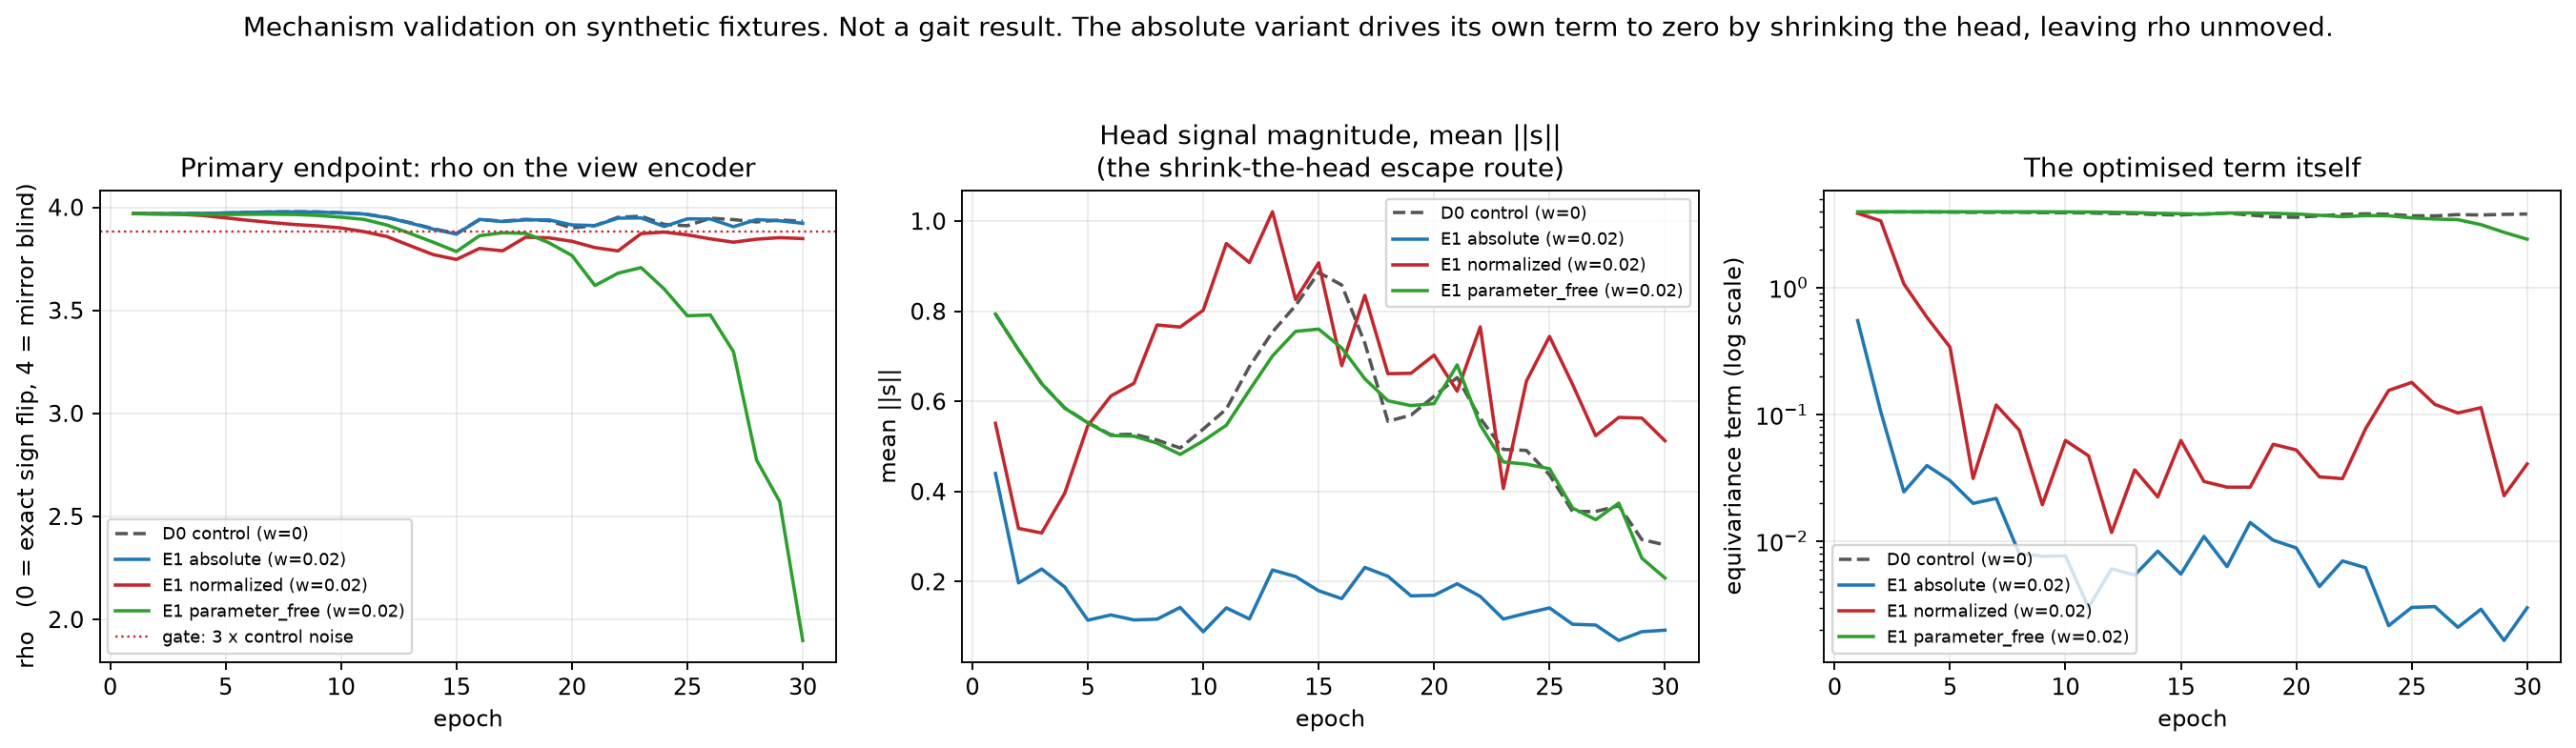

wrote /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real/idea9_arm2/idea9_arm2_mechanism_validation.json
the real ladder in new_nb_09_02 must use variant: parameter_free


In [7]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

COLOURS = {"D0 control (w=0)": "#555555", f"E1 absolute (w={MINI_EQUIV_WEIGHT})": "#1f77b4",
           f"E1 normalized (w={MINI_EQUIV_WEIGHT})": "#c1272d",
           f"E1 parameter_free (w={MINI_EQUIV_WEIGHT})": "#2ca02c"}
figure, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for label, frame in mini_runs.items():
    style = "--" if label.startswith("D0") else "-"
    axes[0].plot(frame["epoch"], frame["rho_view"], style, label=label, color=COLOURS[label])
    axes[1].plot(frame["epoch"], frame["head_signal_scale"], style, label=label, color=COLOURS[label])
    axes[2].semilogy(frame["epoch"], frame["equiv_term"], style, label=label, color=COLOURS[label])
axes[0].axhline(control_rho - gate_threshold, color="#c1272d", linestyle=":", linewidth=1.0,
                label="gate: 3 x control noise")
axes[0].set_title("Primary endpoint: rho on the view encoder")
axes[0].set_ylabel("rho   (0 = exact sign flip, 4 = mirror blind)")
axes[1].set_title("Head signal magnitude, mean ||s||\n(the shrink-the-head escape route)")
axes[1].set_ylabel("mean ||s||")
axes[2].set_title("The optimised term itself")
axes[2].set_ylabel("equivariance term (log scale)")
for axis in axes:
    axis.set_xlabel("epoch")
    axis.grid(alpha=0.25)
    axis.legend(fontsize=7.5)
figure.suptitle("Mechanism validation on synthetic fixtures. Not a gait result. The absolute variant "
                "drives its own term to zero by shrinking the head, leaving rho unmoved.", y=1.04)
figure.tight_layout()
mechanism_png = ARM2_DIR / "idea9_arm2_mechanism_validation.png"
figure.savefig(mechanism_png, dpi=170, bbox_inches="tight")
plt.close(figure)
display(Image(filename=str(mechanism_png)))

MECHANISM = {
    "notebook": "new_nb_09_01_mechanism_and_smoke_validation",
    "mode": "smoke (synthetic fixtures only; not a gait result)",
    "check_1_head_only_is_a_no_op": {
        "wiring_slope": wiring_slope, "loss_value": head_only_value,
        "gradient_into_head": head_only_grad, "passed": True,
        "meaning": "penalising a swap of the head's own tokens is an algebraic identity: zero loss, zero "
                   "gradient, trains nothing.",
    },
    "check_2_through_encoder_reaches_the_encoder": {
        "by_variant": gradient_evidence, "passed": True,
        "meaning": "mirroring the raw skeleton and running both versions through the encoder makes every "
                   "variant a genuine constraint on encoder weights.",
    },
    "check_3_rho_calibration": {
        "rho_by_encoder": calibration_rho, "involution_gap": involution_gap, "passed": True,
        "meaning": "rho reads 0 at exact mirror equivariance and 4 at exact mirror blindness, so its "
                   "scale means what the contract says.",
    },
    "check_4_variant_bakeoff": {
        "epochs": MINI_EPOCHS, "equiv_weight": MINI_EQUIV_WEIGHT,
        "control_rho_view": control_rho,
        "control_late_epoch_std": control_noise,
        "gate_multiple": GATE_MULTIPLE, "gate_threshold": gate_threshold,
        "rows": bakeoff_rows,
        "selected_variant": SELECTED_VARIANT,
        "passed": True,
        "meaning": "the absolute variant satisfies itself by shrinking the head's output rather than "
                   "changing the encoder, so rho does not move. A scale-invariant variant removes that "
                   "escape route and does move rho by more than the control rung's trajectory noise.",
    },
    "gate_for_the_real_ladder": "PASSED",
    "selected_variant_for_the_real_ladder": SELECTED_VARIANT,
    "figure": mechanism_png.name,
    "trajectories": {label: frame.to_dict(orient="list") for label, frame in mini_runs.items()},
}
mechanism_path = ARM2_DIR / "idea9_arm2_mechanism_validation.json"
mechanism_path.write_text(json.dumps(MECHANISM, indent=2), encoding="utf-8")
print(f"wrote {mechanism_path}")
print(f"the real ladder in new_nb_09_02 must use variant: {SELECTED_VARIANT}")

## 5. What this notebook has established, and what comes next

Five things, none of them about gait. Every number below is a **synthetic fixture** from 30 synthetic
sequences over 30 epochs on a toy model.

1. **The head-only formulation is an exact no-op,** measured rather than argued: loss 0.0 and gradient
   into the head 0.0, with the head's wiring confirmed antisymmetric at a slope of -1 to floating point.
2. **The through-the-encoder forms are genuine constraints.** All three deliver gradient to encoder
   weights, with encoder gradient norms of 0.522 for `absolute`, 6.120 for `normalized`, and 1.873 for
   `parameter_free`. `parameter_free` delivers exactly zero into the head, by construction.
3. **The primary endpoint is calibrated.** rho reads exactly 0.0 on an encoder built to be
   mirror-equivariant and exactly 4.0 on one built to be mirror-blind, with an involution gap of 0.0. The
   scale in the contract is the scale the numbers are on.
4. **The registered form of the term has a degenerate solution,** and this is the finding that changed
   the design. Because the head is trainable and the `absolute` residual is an unnormalised squared
   magnitude, the optimiser can satisfy the term by shrinking the head's output instead of changing the
   encoder. That is what it did: the term fell 184.16-fold while the head's signal shrank 4.77-fold and
   rho moved by only 0.0096 against a gate of 0.0492. The loss curve gave no warning whatsoever. Had this
   series simply followed `nb_09b`'s section 8 recipe, it would have spent hours of real compute on a
   term that teaches the encoder nothing, and the resulting curves would have looked like a success.
5. **The repair works.** Dividing the residual by the mean squared norm of the two branches removes the
   escape route, because shrinking the head no longer changes the value. Both scale-invariant forms clear
   the gate, `normalized` by 0.0838 and `parameter_free` by 2.034. `parameter_free` is selected for the
   real ladder, and it is recorded in the bundle: it has no head parameters at all, so the degenerate
   solution is unavailable to it by construction.

### One retraction, kept on the page on purpose

An earlier version of this notebook read a forecast into an incidental observation, and the error is
instructive enough to leave visible rather than delete.

The observation: every encoder measured on this page, randomly initialised or trained, sits near
**rho = 3.9**, close to the mirror-blind end of the scale. The tempting inference was that if real
encoders sit in the same place, then this architecture barely distinguishes a body from its reflection,
which would explain Idea 5's informative null and arm 1's artifact verdict in one stroke.

The real ladder contradicted that forecast. The real control rungs, with the equivariance term switched
off entirely, average **rho 0.462** on the target encoder and land between 0.513 and 0.601 on the view
encoder, over the 3 seeds the ladder ran against the 5 registered. Far closer to mirror-honest than to mirror-blind. A full-width encoder trained
on the real curriculum arrives most of the way to mirror consistency without being asked to.

The reason the fixtures sit at 3.9 is that the toy encoder's mirror blindness is a **design choice**
here, made so that check 3 would have exact known answers, not an empirical finding about architectures.
So the lesson is this: **a synthetic fixture can establish that a measurement means what you claim while
telling you nothing at all about where real data will land on it.** Those two roles are easy to conflate,
and the conflation is easiest when the fixture number is vivid.

### What remains open

Whether the effect survives at real scale, on real pose data, across seeds, and whether it costs
anything in representation quality. Nothing on this page speaks to any of those.

**Next.** `new_nb_09_02` spends the real compute: the full five-stage curriculum, twice per seed, with
`parameter_free` at weight 0.02 as the treatment and weight 0.0 as the control. It reports and does not
judge; the verdict waits for `new_nb_09_03`.
